 GRUPITÖÖ

INSTALLIMINE, ANDMETEGA HÄÄLESTAMINE/LUGEMINE

In [17]:
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import duckdb as dd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [19]:
bolt_andmed = bolt_andmed= pd.read_csv("2026 Vali Andmetarkus grupitöö_Bolt.csv - Bolt test.csv")


In [20]:
bolt_harjutus = bolt_andmed.copy()

## PÕHIANDMESTIKU TULPADE NIMISTIK

In [103]:
for col in bolt_andmed.columns:
    print(f"{col},")

order_id_new,
order_try_id_new,
calc_created,
metered_price,
upfront_price,
distance,
duration,
gps_confidence,
entered_by,
b_state,
dest_change_number,
prediction_price_type,
predicted_distance,
predicted_duration,
change_reason_pricing,
ticket_id_new,
device_token,
rider_app_version,
order_state,
order_try_state,
driver_app_version,
driver_device_uid_new,
device_name,
eu_indicator,
overpaid_ride_ticket,
fraud_score,
duration_difference,
test_train,
overcharge_status,
distance_difference,


In [105]:
df_model = train_model.copy()

# JUHENDAJA poolsed küsimused kohtumistelt

## Kas ticket_id_new'l on mõni tugev/kasulik tunnus ja seotuvus order_id_new'ga?


In [106]:
pd.crosstab(
    df_model["ticket_id_new"].notna(),
    df_model["overpaid_ride_ticket"],
    normalize="index"
) * 100

overpaid_ride_ticket,0,1
ticket_id_new,,
True,97.180135,2.819865


* Võrdluses ülemakstud sõitude piletitega näitab risttabel, et puudub seos ja info, mis võiks oll kasulik põhiküsimuse vastamiseks

## Overcharge statuse ja overpaid ride piletite võrdlus

In [53]:
pd.crosstab(
    bolt_andmed["overcharge_status"],
    bolt_andmed["overpaid_ride_ticket"],
    normalize="index"
) * 100

overpaid_ride_ticket,0,1
overcharge_status,,
NO OVERCHARGE,96.967560,3.032440
OVERCHARGE,96.735309,3.264691
UNKNOWN,85.071708,14.928292


## MÕÕDIKUD

In [25]:
bolt_andmed["duration_difference"] = (
    bolt_andmed["duration"] - bolt_andmed["predicted_duration"]
)

In [26]:
np.random.seed(42)

n_samples = len(bolt_andmed)
n_test = int(0.3 * n_samples)
split_flags = np.zeros(n_samples, dtype=int)
test_indices = np.random.choice(n_samples, size=n_test, replace=False)
split_flags[test_indices] = 1

bolt_andmed["test_train"] = split_flags


# LINEAARREGRESSIOON

## TRAIN ja TEST data sidumine põhiandmestikuga + vääringute seadmine

In [27]:
train_data = bolt_andmed[bolt_andmed["test_train"] == 0]

test_data = bolt_andmed[bolt_andmed["test_train"] == 1]

* LinearRegression install

In [28]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()



## TRAIN ETTEVALMISTUS : grupeerimine, aja tähenduse muutmine calc_created tulbas

In [29]:
features = [
    "distance",
    "predicted_distance",
    "predicted_duration",
    "gps_confidence",
    "upfront_price",
    "year",
    "month",
    "hour",
    "weekday",
    "metered_price",
    "dest_change_number",
    "eu_indicator",
    "ticket_id_new"
]

train_data["year"] = pd.to_datetime(train_data["calc_created"]).dt.year
train_data["month"] = pd.to_datetime(train_data["calc_created"]).dt.month
train_data["hour"] = pd.to_datetime(train_data["calc_created"]).dt.hour
train_data["weekday"] = pd.to_datetime(train_data["calc_created"]).dt.weekday
train_model = train_data.dropna(subset=features + ["duration"])



## TEST DATA ETTEVALMISTUS

In [30]:
test_data["calc_created"] = pd.to_datetime(test_data["calc_created"])

test_data["year"] = test_data["calc_created"].dt.year
test_data["month"] = test_data["calc_created"].dt.month
test_data["hour"] = test_data["calc_created"].dt.hour
test_data["weekday"] = test_data["calc_created"].dt.weekday

## Train ja Test andmete NaNidest puhastamine

In [31]:
train_model = train_data.dropna(subset=features + ["duration"])
test_model = test_data.dropna(subset=features)


## MUDELI TREENIMINE/FITTIMINE

In [32]:

model.fit(
    train_model[features],
    train_model["duration"]
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 0.07, -0.08, 1.18,..., 166.48,-313.84, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['distance','predicted_distance','predicted_duration',..., 'dest_change_number','eu_indicator','ticket_id_new']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,161
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


## Ennustamise häälestus mudeli külge (test_model)

In [33]:
duration_result = model.predict(test_model[features])

In [34]:
from sklearn.metrics import r2_score

## Test mudeli R2 skoor

In [35]:
r2_score(
    test_model["duration"],
    duration_result
)

0.5944534324110684

## Scatterplot x= distance, y= duration

<Axes: xlabel='distance', ylabel='duration'>

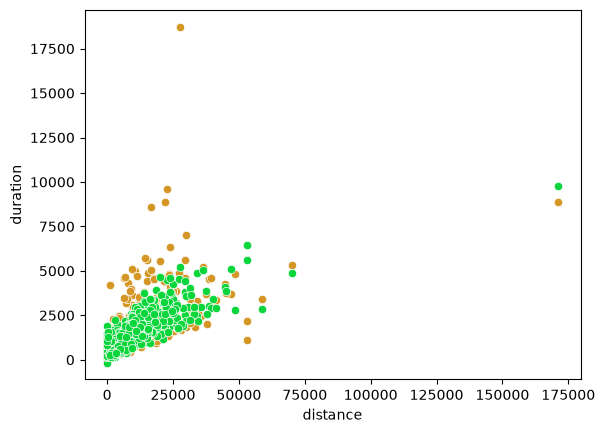

In [36]:
sns.scatterplot(test_model, x="distance", y="duration", color="#D49725")
sns.scatterplot(x=test_model["distance"], y=duration_result, color="#0AD53A")

* Test mudeli: upfront_price, metered_price, predicted_distance ja predicted_duration korrelatsiooni tabel

In [37]:
test_model[
    ["upfront_price", "metered_price", "predicted_distance", "predicted_duration"]
].corr()

,upfront_price,metered_price,predicted_distance,predicted_duration
upfront_price,1.000000,0.393613,0.693056,0.755825
metered_price,0.393613,1.000000,0.161267,0.372521
predicted_distance,0.693056,0.161267,1.000000,0.905041
predicted_duration,0.755825,0.372521,0.905041,1.000000


(0.0, 10000.0)

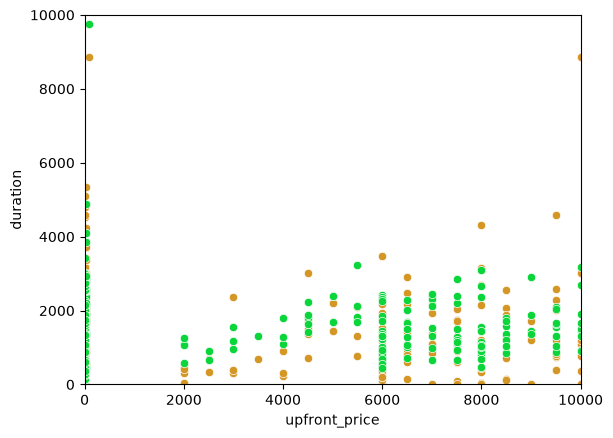

In [38]:
sns.scatterplot(test_model, x="upfront_price", y="duration", color="#D49725")
sns.scatterplot(
    x=test_model["upfront_price"],
    y=duration_result,
    color="#0AD53A"
)

plt.xlim(0, 10000)
plt.ylim(0, 10000)

# Overpaid_ride piletid

In [39]:
bolt_andmed["overpaid_ride_ticket"].value_counts()

overpaid_ride_ticket
0    4606
1     337
Name: count, dtype: int64

## Ennustatava sõiduaja vs päris sõiduaja võrdlus overpaid_ride piletitega

(0.0, 10000.0)

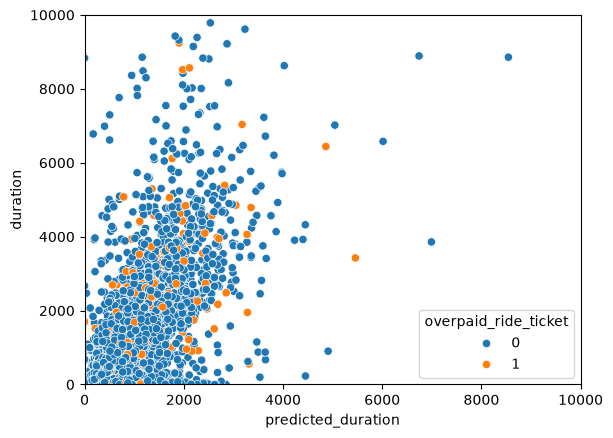

In [40]:
sns.scatterplot(
    data=bolt_andmed, 
    x="predicted_duration", 
    y="duration",
    hue= "overpaid_ride_ticket"
)

plt.xlim(0, 10000)
plt.ylim(0, 10000)

## GPS signaal

#  vs Overpaid_Ride piletid - HEATMAP võrdlus

<Axes: xlabel='overpaid_ride_ticket', ylabel='gps_confidence'>

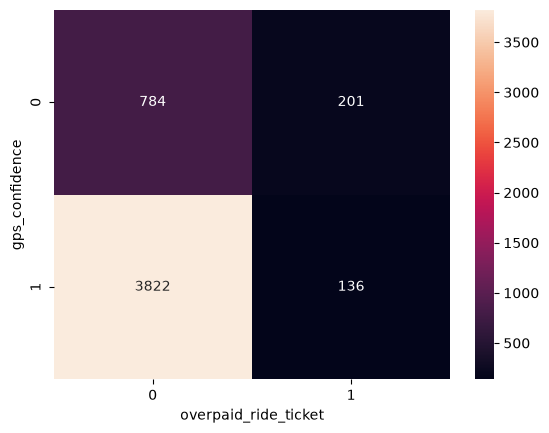

In [41]:
sns.heatmap(
    pd.crosstab(
        bolt_andmed["gps_confidence"],
        bolt_andmed["overpaid_ride_ticket"]
    ),
    annot=True,
    fmt="d"
)



# vs Overpaid_ride piletite suhe

In [42]:
gps_analysis = (
    bolt_andmed
    .groupby("gps_confidence")
    .agg(
        sõite=("overpaid_ride_ticket", "count"),
        overcharge_ticketid=("overpaid_ride_ticket", "sum"),
        overcharge_rate=("overpaid_ride_ticket", "mean")
    )
)

gps_analysis["overcharge_rate"] = gps_analysis["overcharge_rate"] * 100

gps_analysis

,sõite,overcharge_ticketid,overcharge_rate
gps_confidence,,,
0,985,201,20.406091
1,3958,136,3.436079


# vs Overcharge piletite suhe ennustatud tüübiga 

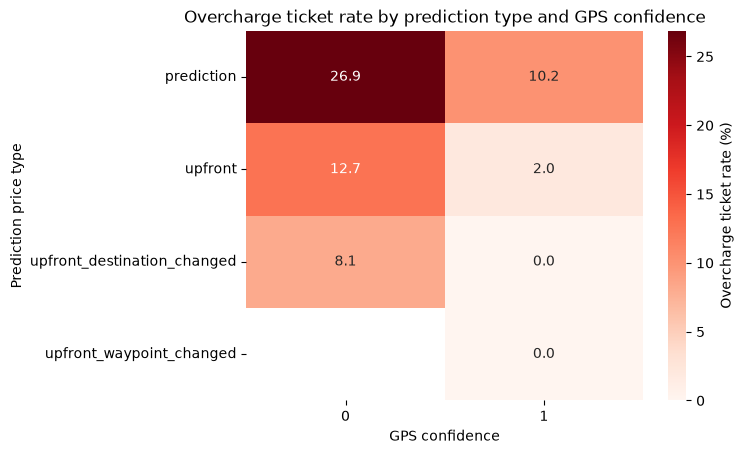

In [44]:
heatmap_data = pd.crosstab(
    bolt_andmed["prediction_price_type"],
    bolt_andmed["gps_confidence"],
    values=bolt_andmed["overpaid_ride_ticket"],
    aggfunc="mean"
) * 100

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Overcharge ticket rate (%)"}
)

plt.title("Overcharge ticket rate by prediction type and GPS confidence")
plt.xlabel("GPS confidence")
plt.ylabel("Prediction price type")
plt.show()

## Hinnastamise tüübi analüüs 

In [45]:
price_type_analysis = (
    bolt_andmed
    .groupby("prediction_price_type")
    .agg(
        sõite=("overpaid_ride_ticket", "count"),
        overcharge_ticketid=("overpaid_ride_ticket", "sum"),
        overcharge_rate=("overpaid_ride_ticket", "mean")
    )
)

price_type_analysis["overcharge_rate"] *= 100

price_type_analysis

,sõite,overcharge_ticketid,overcharge_rate
prediction_price_type,,,
prediction,1279,222,17.357310
upfront,3432,112,3.263403
upfront_destination_changed,208,3,1.442308
upfront_waypoint_changed,4,0,0.000000


## Ennustatud vs actual distance

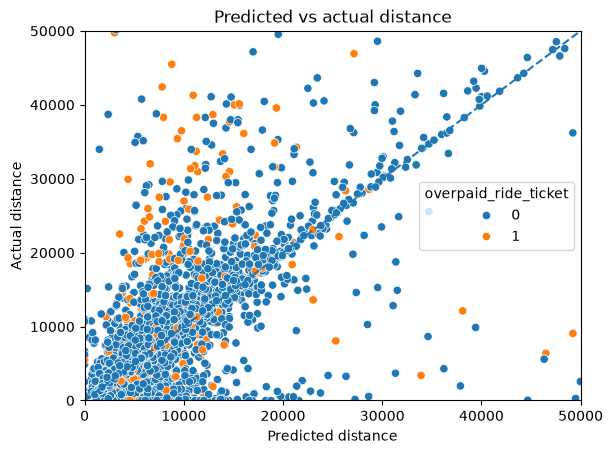

In [46]:
sns.scatterplot(
    data=bolt_andmed,
    x="predicted_distance",
    y="distance",
    hue="overpaid_ride_ticket"
)
plt.xlim(0, 50000)
plt.ylim(0, 50000)
plt.xlabel("Predicted distance")
plt.ylabel("Actual distance")
plt.title("Predicted vs actual distance")
plt.plot([0, 50000], [0, 50000], linestyle="--")
plt.show()


# Ennustatava sõidutüübi hinnastamise analüüs

## Sõidutüüp vs ennustatud teepikkus vs ennustatud aeg kirjeldav tabel

In [47]:
bolt_andmed.groupby("prediction_price_type")[
    ["predicted_distance", "predicted_duration"]
].describe()

predicted_distance                              \
                                         count          mean           std   
prediction_price_type                                                        
prediction                              1279.0   9528.620016   7507.856170   
upfront                                 3432.0   8479.618590  11040.286487   
upfront_destination_changed              208.0   9997.163462  16426.958121   
upfront_waypoint_changed                   4.0  16318.750000   4469.073832   

                                                                            \
                                min       25%      50%       75%       max   
prediction_price_type                                                        
prediction                      0.0   5218.00   8327.0  11240.00   96296.0   
upfront                        21.0   3876.75   6371.0  10337.50  353538.0   
upfront_destination_changed     0.0   3810.75   7252.0  11694.00  217444.0   
upfront_waypoint_changed     9726.0  15889.50  17944.0  18373.25   19661.0   

                            predicted_duration                           \
                                         count         mean         std   
prediction_price_type                                                     
prediction                              1279.0  1390.874902  739.515838   
upfront                                 3432.0  1009.167832  802.177073   
upfront_destination_changed              208.0   954.961538  841.651510   
upfront_waypoint_changed                   4.0  1860.750000  803.060137   

                                                                       
                               min      25%     50%      75%      max  
prediction_price_type                                                  
prediction                     0.0   879.50  1291.0  1792.00   6991.0  
upfront                        2.0   552.75   841.0  1251.75  20992.0  
upfront_destination_changed    0.0   522.75   807.5  1181.25   9893.0  
upfront_waypoint_changed     823.0  1428.25  2062.5  2495.00   2495.0

# Ennustatava sõidutüübi korrelatsioon GPS signaaliga

In [48]:
prediction_data = bolt_andmed[
    bolt_andmed["prediction_price_type"] == "prediction"
]

for gps in [0, 1]:
    subset = prediction_data[prediction_data["gps_confidence"] == gps]
    print(
        "GPS", gps,
        "korrelatsioon:",
        subset["predicted_distance"].corr(subset["distance"])
    )

GPS 0 korrelatsioon: 0.44123653088370457
GPS 1 korrelatsioon: 0.6332633478213355


## Ennustatava sõidutüübi võrdlus upfront hinnastamise + metered_price 

In [49]:
bolt_andmed.groupby("prediction_price_type")[
    ["upfront_price", "metered_price"]
].describe()

upfront_price                                  \
                                    count         mean           std  min   
prediction_price_type                                                       
prediction                            0.0          NaN           NaN  NaN   
upfront                            3409.0  4160.095747  17015.711912  2.0   
upfront_destination_changed           0.0          NaN           NaN  NaN   
upfront_waypoint_changed              0.0          NaN           NaN  NaN   

                                                        metered_price  \
                             25%  50%     75%       max         count   
prediction_price_type                                                   
prediction                   NaN  NaN     NaN       NaN        1279.0   
upfront                      4.2  6.6  4000.0  595000.0        3432.0   
upfront_destination_changed  NaN  NaN     NaN       NaN         208.0   
upfront_waypoint_changed     NaN  NaN     NaN       NaN           4.0   

                                                                         \
                                     mean           std   min       25%   
prediction_price_type                                                     
prediction                   17175.171298  17040.853407  6.73  6646.440   
upfront                       4965.889531  14263.831436  2.00     4.460   
upfront_destination_changed   1761.735817   8340.485958  2.43     6.375   
upfront_waypoint_changed        14.045000      5.231988  6.89    11.765   

                                                              
                                   50%        75%        max  
prediction_price_type                                         
prediction                   13023.540  20519.520  157006.04  
upfront                          7.385   2000.000  194483.52  
upfront_destination_changed     10.205     19.965   72871.72  
upfront_waypoint_changed        15.670     17.950      17.95

## Ennustatava sõidutüübi võrdlus actual aja ja teepikkusega

In [50]:
bolt_andmed.groupby("prediction_price_type")[
    ["distance", "duration"]
].describe()

distance                                      \
                               count          mean           std     min   
prediction_price_type                                                      
prediction                    1279.0  10597.084441  10170.642430     0.0   
upfront                       3432.0   9035.663462  10068.343572     0.0   
upfront_destination_changed    208.0  16865.615385  21332.920810     1.0   
upfront_waypoint_changed         4.0  15959.750000   4407.720528  9584.0   

                                                                   duration  \
                                  25%      50%       75%       max    count   
prediction_price_type                                                         
prediction                    4194.00   8688.0  13002.00   78854.0   1279.0   
upfront                       3634.75   6551.5  11250.50  171119.0   3432.0   
upfront_destination_changed   6166.25  10444.0  18618.25  233190.0    208.0   
upfront_waypoint_changed     15341.00  17260.0  17878.75   19735.0      4.0   

                                                                              \
                                    mean          std    min     25%     50%   
prediction_price_type                                                          
prediction                   2331.713839  2089.037472    0.0   930.5  1851.0   
upfront                      1251.901224  1322.940340    0.0   541.0   895.0   
upfront_destination_changed  2063.644231  1846.974829  374.0   952.0  1512.0   
upfront_waypoint_changed     2127.500000  1007.697210  862.0  1543.0  2354.5   

                                               
                                 75%      max  
prediction_price_type                          
prediction                   3142.50  22402.0  
upfront                      1448.25  18734.0  
upfront_destination_changed  2514.00  15618.0  
upfront_waypoint_changed     2939.00   2939.0

# Ülehinnatud sõitude staatus tulba loomine / analüüs 

In [51]:
import numpy as np

## Staatuste kategoriseerimine

In [52]:
bolt_andmed["overcharge_status"] = np.where(
    bolt_andmed["upfront_price"].isna(),
    "UNKNOWN",
    np.where(
        bolt_andmed["metered_price"]> bolt_andmed["upfront_price"],
        "OVERCHARGE",
        "NO OVERCHARGE"
    )
)

## Kontroll

In [56]:
bolt_andmed["overcharge_status"].value_counts()

overcharge_status
OVERCHARGE       1991
UNKNOWN          1534
NO OVERCHARGE    1418
Name: count, dtype: int64

# Ülehinnastatud sõitude võrdlus VS kliendi kaebus ülehinnatud sõidu kohta

In [57]:
pd.crosstab(
    bolt_andmed["overpaid_ride_ticket"],
    bolt_andmed["overcharge_status"]
)

overcharge_status,NO OVERCHARGE,OVERCHARGE,UNKNOWN
overpaid_ride_ticket,,,
0,1375,1926,1305
1,43,65,229


## Ülehinnatud sõitude võrdlus EU indikaatoriga

In [ ]:
pd.crosstab(
    bolt_andmed["eu_indicator"],
    bolt_andmed["overcharge_status"]
)

overcharge_status,NO OVERCHARGE,OVERCHARGE,UNKNOWN
eu_indicator,,,
0,367,515,1291
1,1051,1476,243


## Sõitude staatuse järgi ristvõrdlus EU, GPS (index) näitel

In [58]:
pd.crosstab(
    bolt_andmed["overcharge_status"],
    [bolt_andmed["eu_indicator"], bolt_andmed["gps_confidence"]],
    normalize="index"
) * 100

eu_indicator               0                    1           
gps_confidence             0          1         0          1
overcharge_status                                           
NO OVERCHARGE       6.488011  19.393512  1.833568  72.284908
OVERCHARGE         10.296334  15.570065  2.461075  71.672526
UNKNOWN            36.571056  47.588005  3.389831  12.451108

# RandomForest Classifier I loomine

# x telg EU, GPS ja y telg ülehinnatud sõitude staatus

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = bolt_andmed[["eu_indicator", "gps_confidence"]]
y = bolt_andmed["overcharge_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Ennustuse seadistus x_test

In [60]:
probs = model.predict_proba(X_test)

* Mudeli kategoriseerimise kontroll

In [61]:
model.classes_

array(['NO OVERCHARGE', 'OVERCHARGE', 'UNKNOWN'], dtype=object)

* Mudeli data kombinatsioonide seadistus + liitmine tõenäosusega

In [63]:
kombinatsioonid = pd.DataFrame({
    "eu_indicator": [0, 0, 1, 1],
    "gps_confidence": [0, 1, 0, 1]
})

mudeli_tõenäosused = model.predict_proba(X_test)

mudeli_tõenäosused

array([[0.11308098, 0.23353901, 0.65338002],
       [0.20198681, 0.24342198, 0.5545912 ],
       [0.3850594 , 0.53714226, 0.07779834],
       ...,
       [0.3850594 , 0.53714226, 0.07779834],
       [0.20198681, 0.24342198, 0.5545912 ],
       [0.3850594 , 0.53714226, 0.07779834]], shape=(989, 3))

* Mudeli data sidumine prognoosiga

In [64]:
prognoos = pd.DataFrame(
    mudeli_tõenäosused,
    columns=model.classes_
)

prognoos["eu_indicator"] = X_test["eu_indicator"].values
prognoos["gps_confidence"] = X_test["gps_confidence"].values

In [65]:
## Prognoosi 

## RandomForest prognoos sõidu kategooriate järgi võrdluses EU ja GPS näitel

In [67]:
prognoos.head()

,NO OVERCHARGE,OVERCHARGE,UNKNOWN,eu_indicator,gps_confidence
0,0.113081,0.233539,0.653380,0,0
1,0.201987,0.243422,0.554591,0,1
2,0.385059,0.537142,0.077798,1,1
3,0.113081,0.233539,0.653380,0,0
4,0.385059,0.537142,0.077798,1,1


In [69]:
prognoos_pikk = prognoos.melt(
    id_vars=["EU_GPS"],
    value_vars=["NO OVERCHARGE", "OVERCHARGE", "UNKNOWN"],
    var_name="staatus",
    value_name="tõenäosus"
)

# HÜPOTEES I
"Kui väljaspool EU parandada GPS-i usaldusväärsust, võib see vähendada "unknown" juhtumite osakaalu ja potensiaalselt muuta hinnastamise täpsust.

EU = 0

GPS confidence 0: 39.5%

GPS confidence 1: 60.5%

UNKNOWN: 59.4%

EU = 1

GPS confidence 0: 4.6%

GPS confidence 1: 95.4%

UNKNOWN: 8.8%

# KÕIKIDE SÕITUDE VÕRDLUS (POS ja NEG IMPACT)

In [72]:
prognoos["OVERCHARGE_tsoon"] = pd.cut(
    prognoos["OVERCHARGE"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=["0–0.25", "0.25–0.50", "0.50–0.75", "0.75–1.00"],
    include_lowest=True
)

In [107]:
X = model_data[
    ["eu_indicator", "gps_confidence", "upfront_price", "metered_price"]
]

y = model_data["overcharge_status"]

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [109]:
model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [110]:
mudeli_tõenäosused_all = model.predict_proba(X)

prognoos_all = pd.DataFrame(
    mudeli_tõenäosused_all,
    columns=model.classes_
)

In [111]:
prognoos_all["OVERCHARGE_tsoon"] = pd.cut(
    prognoos_all["OVERCHARGE"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=["0–0.25", "0.25–0.50", "0.50–0.75", "0.75–1.00"],
    include_lowest=True
)

In [112]:
prognoos_all["OVERCHARGE_tsoon"].value_counts().sort_index()

OVERCHARGE_tsoon
0–0.25       1375
0.25–0.50      43
0.50–0.75      60
0.75–1.00    1931
Name: count, dtype: int64

In [118]:
model_data = bolt_andmed[
    bolt_andmed["overcharge_status"] != "UNKNOWN"
].copy()

## JÄRELDUS, KOGU ANDMESTIKU ALUSEL "overcharge staatuse" kategoriseerimisel hinnastamise loogika alusel (upfront_price < metered_price) EI saa võtta aluseks KOGU andmestikku, kuna 1534 SÕITU / kogu summast 4943 on UNKNOWN (puudub hinnastamiseinfo ning otsides loogikat mujalt KOGU andmestikust ei õnnestunud leida sobilik loogika) mistõttu ei ole andmed sobilikud lõppjärelduse tegemiseks - OTSUS: Keskenduda vaid Overcharge ja No Overcharge juhtumite/sõitudele.

## UUS ANDMESTIK , kus on välja filtreeritud "UNKNOWN" sõidud

In [119]:
bolt_andmed_uuendatud = bolt_andmed[
    bolt_andmed["upfront_price"].notna()
].copy()

In [120]:
bolt_andmed_uuendatud.shape

(3409, 30)

## Analüüs hõlmab 3409 sõitu, mille puhul olid olemas mõlemad overcharge-staatuse määramiseks vajalikud hinnaväljad. 1534 sõitu jäeti analüüsist välja, kuna upfront_price puudus ning nende puhul ei olnud võimalik rakendada kasutatud overcharge'i definitsiooni.

## OVERCHARGE / NO OVERCHARGE sõitudel puudub seos EU indikaatorist

In [121]:
bolt_andmed_uuendatud.groupby("eu_indicator")["overcharge_status"].value_counts(normalize=True)

eu_indicator  overcharge_status
0             OVERCHARGE           0.583900
              NO OVERCHARGE        0.416100
1             OVERCHARGE           0.584092
              NO OVERCHARGE        0.415908
Name: proportion, dtype: float64

## MINIMAALNE SEOS OVERCHARGE / NO OVERCHARGE sõitudel GPS signaaliga

In [97]:
bolt_andmed_uuendatud.groupby("gps_confidence")["overcharge_status"].value_counts(normalize=True)

gps_confidence  overcharge_status
0               OVERCHARGE           0.682796
                NO OVERCHARGE        0.317204
1               OVERCHARGE           0.571946
                NO OVERCHARGE        0.428054
Name: proportion, dtype: float64

* OVERCHARGE ja NO OVERCHARGE keskmise arvutamine Uprfront_price ja metered_price võrdluses

In [123]:
bolt_andmed_uuendatud.groupby("overcharge_status")[
    ["upfront_price", "metered_price"]
].mean()

,upfront_price,metered_price
overcharge_status,,
NO OVERCHARGE,4719.528773,2495.741495
OVERCHARGE,3761.664792,6782.346876


* OVERCHARGE ja NO OVERCHARGE KORRELATSIOON LOGARITMIGA

In [124]:
bolt_andmed_uuendatud[
    ["upfront_price", "metered_price"]
].corr()

,upfront_price,metered_price
upfront_price,1.000000,0.420772
metered_price,0.420772,1.000000


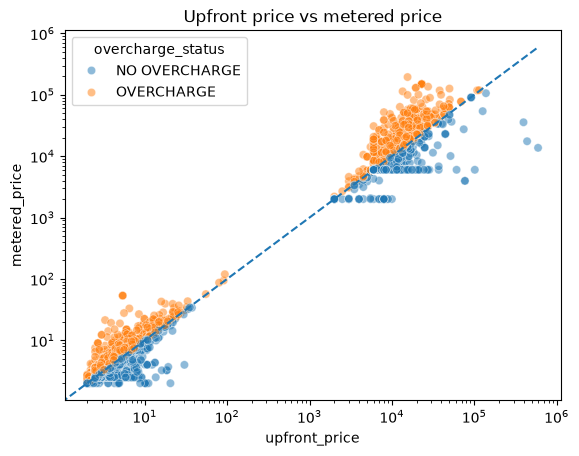

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=bolt_andmed_uuendatud,
    x="upfront_price",
    y="metered_price",
    hue="overcharge_status",
    alpha=0.5
)

plt.plot(
    [0, bolt_andmed_uuendatud["upfront_price"].max()],
    [0, bolt_andmed_uuendatud["upfront_price"].max()],
    linestyle="--"
)

plt.xscale("log")
plt.yscale("log")
plt.title("Upfront price vs metered price")
plt.show()

UPFRONT_PRICE ENNUSTUSE/PROGNOOSI TEOSTAMINE LÄBI MUDELI

In [132]:
features = [
    "metered_price",
    "distance",
    "duration",
    "gps_confidence",
    "dest_change_number",
    "predicted_distance",
    "predicted_duration",
]

X = np.log1p(
    df_model[features]
)

y = np.log1p(
    df_model["upfront_price"]
)

In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [130]:
from sklearn.linear_model import LinearRegression

log_model = LinearRegression()

log_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.99,-0.07,-0.18,...,-0.04, 0.14, 0.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['metered_price','distance','duration',...,'dest_change_number', 'predicted_distance','predicted_duration']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.9317
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


* TEST ANDMETE PEAL MUDELI TESTIMINE + KONTROLL (R2, MAE)

In [134]:
y_pred_log = log_model.predict(X_test)

In [136]:
y_pred = np.expm1(y_pred_log)

In [137]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(
    np.expm1(y_test),
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred_log
)

mae, r2

(1632.2235697728963, 0.9926103842985387)

## Log LineaarRegression kontroll MAE

In [138]:
mask = np.expm1(y_test) < 100

mae_under_100 = mean_absolute_error(
    np.expm1(y_test[mask]),
    y_pred[mask]
)

mae_under_100

0.8495492857813458

## Log LineaarRegression mudeli tulemus

In [139]:
comparison_under_100 = pd.DataFrame({
    "actual": np.expm1(y_test[mask]).values,
    "predicted": y_pred[mask]
})

comparison_under_100.head(20)

,actual,predicted
0,6.3,6.860069
1,4.2,4.013194
2,4.0,3.573771
3,5.0,5.516304
4,8.9,9.475690
5,3.8,2.948869
6,32.0,36.400291
7,6.5,5.866478
8,4.0,6.066176
9,3.1,3.129460


* 4 SÕIDU MUUTMINE vääringuks 0, kuna Logaritmilist visuaali ei saa luua negatiivse vääringuga

* KATEGOORIA OBSERVED (päriselt andmestikus olemas olnud hind) loomine

In [144]:
df_model["upfront_price_source"] = "observed"

In [145]:
df_model["upfront_price_source"].value_counts()

upfront_price_source
observed    2376
Name: count, dtype: int64

In [155]:
df_model["metered_to_upfront_ratio"] = (
    df_model["metered_price"] /
    df_model["upfront_price"]
)

In [156]:
df_model["overcharge_status"] = np.where(
    df_model["metered_price"] > df_model["upfront_price"],
    "OVERCHARGE",
    "NO OVERCHARGE"
)

pd.cut(
    df_model["metered_to_upfront_ratio"],
    bins=[0, 1, 1.10, 1.25, 1.50, np.inf],
    labels=[
        "Alla 1.00",
        "1.00–1.10",
        "1.10–1.25",
        "1.25–1.50",
        "Üle 1.50"
    ]
).groupby(
    df_model["overcharge_status"]
).value_counts().unstack(fill_value=0)

metered_to_upfront_ratio,Alla 1.00,1.00–1.10,1.10–1.25,1.25–1.50,Üle 1.50
overcharge_status,,,,,
NO OVERCHARGE,962,0,0,0,0
OVERCHARGE,0,367,375,393,279


# HARJUTUS MUDELI FIT (youtube:dataprofessor)

* Andmete eraldamine X ja Y teljeks

* HARJUTUS ANDMETEST tulpade filtreerimine valikulisuse järgi

In [160]:
bolt_harjutus = bolt_andmed[[
    "distance",
    "order_id_new",
    "order_try_id_new",
    "calc_created",
    "metered_price",
    "upfront_price",
    "duration",
    "gps_confidence",
    "driver_app_version",
    "driver_device_uid_new",
    "eu_indicator",
    "overpaid_ride_ticket",
    "fraud_score",
    "device_name",
    "duration_difference"
]].copy()

* HOUR tulba liitmine bolt-andmetega

In [161]:
bolt_harjutus["calc_created"] = pd.to_datetime(
    bolt_harjutus["calc_created"]
)

bolt_harjutus["hour"] = bolt_harjutus["calc_created"].dt.hour

## KAHE TEKSTILISE (String) väärtusega tulpade numbriliseks vääringuks teisendamine

In [163]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=100
)

In [164]:
bolt_harjutus[["driver_app_version", "device_name"]].nunique()

driver_app_version     33
device_name           497
dtype: int64

## Seadmete tükeldamine +  filtreerimine kategooriate järgi

In [165]:
bolt_harjutus["device_brand"] = np.select(
    [
        bolt_harjutus["device_name"].str.contains("TECNO", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("SAMSUNG", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("HUAWEI", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("IPHONE", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("NOKIA|HMD Global", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("ITEL", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("XIAOMI", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("INFINIX", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("LGE|LG", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("FOXCONN", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("ALPS", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("OPPO", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("SONY", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("LAVA", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("ZTE", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("BullittGroup", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("DIGMA", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("LENOVO", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("ASUS", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("SHARP", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("TCL", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("FUJITSU", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("MOTOROLA", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("BLACKVIEW", case=False, na=False),
        bolt_harjutus["device_name"].str.contains("GOOGLE|PIXEL", case=False, na=False)
    ],
    [
        "TECNO", "Samsung", "Huawei", "Apple", "Nokia", "Itel",
        "Xiaomi", "Infinix", "LG", "Foxconn", "Alps", "OPPO",
        "Sony", "LAVA", "ZTE", "BullittGroup", "DIGMA", "Lenovo",
        "Asus", "Sharp", "TCL", "Fujitsu", "Motorola", "Blackview",
        "Google"
    ],
    default="Other"
)

In [167]:
bolt_harjutus["device_brand"].value_counts()

device_brand
Samsung         1683
TECNO            933
Huawei           724
Apple            426
Infinix          266
Xiaomi           261
Nokia            201
Itel             120
Other             67
Sony              46
LG                39
Lenovo            23
Foxconn           23
OPPO              22
BullittGroup      22
Alps              11
Blackview         11
LAVA              10
ZTE               10
Asus               9
DIGMA              7
Sharp              7
TCL                7
Fujitsu            7
Motorola           4
Google             4
Name: count, dtype: int64

## X ja Y teljele uuritava sihtgrupi määramine

## Overcharge staatusele vääringu 0 ja 1 lisamine

In [255]:
y = (bolt_andmed_uuendatud["overcharge_status"] == "OVERCHARGE").astype(int)

In [256]:
y = bolt_andmed_uuendatud["overcharge_status"]

x = bolt_andmed_uuendatud.drop(
    [
        "overcharge_status",
        "metered_price",
        "upfront_price",
        "overpaid_ride_ticket",
        "entered_by",
        "b_state",
        "prediction_price_type",
        "change_reason_pricing",
        "rider_app_version",
        "order_state",
        "order_try_state",
         "calc_created",
         "driver_app_version"
    ],
    axis=1
)

In [259]:

x = pd.get_dummies(
    x,
    columns=[ "device_name"],
    dtype=int
)

In [268]:
x = x.drop("device_token", axis=1)

In [270]:
x["fraud_score"] = x["fraud_score"].fillna(
    x["fraud_score"].median()
)

In [271]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=100
)

In [273]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(x_train, y_train)

c:\Users\Laptopid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [283]:
device_features = x.filter(like="device_name_").shape[1]
other_features = x.shape[1] - device_features

print("Kõik tunnused:", x.shape[1])
print("device_name tunnused:", device_features)
print("Muud tunnused:", other_features)

Kõik tunnused: 439
device_name tunnused: 424
Muud tunnused: 15


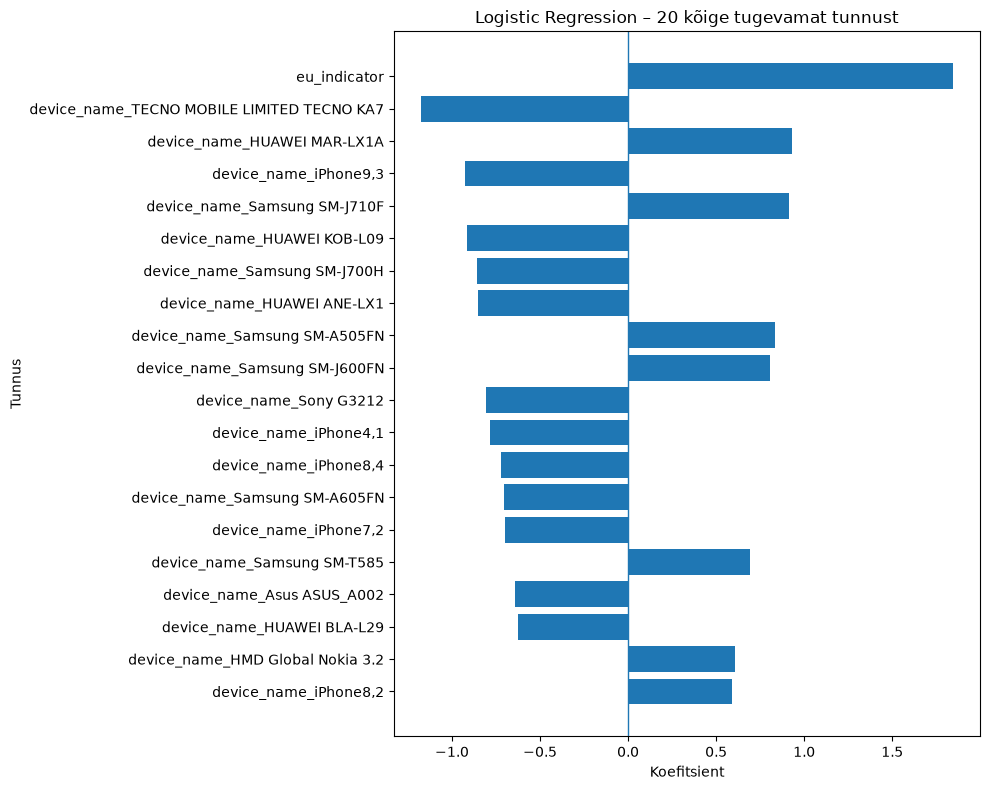

In [298]:
import matplotlib.pyplot as plt

top20 = feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
).head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["feature"],
    top20["coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Logistic Regression – 20 kõige tugevamat tunnust")
plt.xlabel("Koefitsient")
plt.ylabel("Tunnus")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [297]:
x.isna().sum().sort_values(ascending=False).head(20)

order_id_new                   0
order_try_id_new               0
distance                       0
duration                       0
gps_confidence                 0
dest_change_number             0
predicted_distance             0
predicted_duration             0
ticket_id_new                  0
driver_device_uid_new          0
eu_indicator                   0
fraud_score                    0
duration_difference            0
test_train                     0
distance_difference            0
device_name_Alps F9 Pro        0
device_name_Alps TECNO B1p     0
device_name_Asus ASUS_A002     0
device_name_Asus ASUS_X00TD    0
device_name_Asus ASUS_Z012D    0
dtype: int64

* Kuna LogisticRegressioon kaldub tugevalt 0 suunas ehk NO OVERCHARGE siis AI soovitab MUDELILE öelda " Ära pea mõlemat klassi võrdselt sagedaseks. Pööra haruldasele klassile 1 rohkem tähelepanu"

* PÕHJENDUS: Algne mudel tegi sisuliselt "Ma tahan võimalikult vähe eksida üldiselt", mistõttu leidis ta väga palju 0 ehk "overcharged" ja osad nendest olid ka ekslikult leitud, aga pärast mudeli treenimist ja tasakaalustamist: "Ma ei taha, et haruldase klassi vead muutuksid mudeli jaoks sisuliselt tähtsusetuks ehk "Missingness flag" annab mudelile võimaluse õppida, kas väärtuse puudumine ise sisaldab infot ja "class_weight=balanced" annab mudelile põhjuse pöörata haruldasele klassile 1 rohkem tähelepanu". 

In [302]:
lr = LogisticRegression(class_weight="balanced")

lr.fit(x_train, y_train)

c:\Users\Laptopid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the fol

* KONTROLL

In [303]:
y_lr_train_pred = lr.predict(x_train)

print(classification_report(y_train, y_lr_train_pred))

               precision    recall  f1-score   support

NO OVERCHARGE       0.87      0.96      0.91      1112
   OVERCHARGE       0.97      0.90      0.94      1615

     accuracy                           0.93      2727
    macro avg       0.92      0.93      0.92      2727
 weighted avg       0.93      0.93      0.93      2727



* CONFUSION MATRIXI KONTROLL UUELE BALANCED MUDELILE - KONTROLL siis selleks, et kas mudel hakkab normaalseid sõite ka liitma sinna, kuhu ta ei tohiks seda teha

In [304]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, y_lr_train_pred)

array([[1063,   49],
       [ 154, 1461]])

# ENNUSTAME TEST ANDMEID

In [305]:
y_lr_test_pred = lr.predict(x_test)

In [306]:
print(classification_report(y_test, y_lr_test_pred))

               precision    recall  f1-score   support

NO OVERCHARGE       0.89      0.95      0.92       306
   OVERCHARGE       0.95      0.90      0.93       376

     accuracy                           0.92       682
    macro avg       0.92      0.92      0.92       682
 weighted avg       0.92      0.92      0.92       682



* SUPPORT - mitu tegelikku juhtu meil oli? 919 norm sõitu, 70 overcharge sõitu

* RECALL - kui palju tegelikest juhtudest üles leidsime?
Overcharge 70 x 0.63 = 44 sõitu (ehk need päris sõidud, mis olid ka piisava infoga nendest 44 leidis ka treenitud mudel ülesse) = 26 jäi leidmata!

* PRECISION - kui sageli on mudeli leitud juhtum päriselt õige? Kõigist sõitudest, mille sa kuulutasid Overchargeiks, kui palju tegelikult olid overchargid? 0.16 = 16% ehk 70 sõitu on 100%

* F1 SKOOR püüab need kaks üheks numbriks kokku võtta (precision (0.16) + recall (0.63) = F1 Skoor 0.25

* ACCURACY - 0.73 ehk kõigist 989 testsõidust klassifitseeris mudel õigesti umbes 73%






## "Kas me suudame saada praegusest 0.25-st parema precision/recall kompromissi ja mis hinnaga?"

* Otsustuslävend, logisticregression annab tõenäosuse

In [307]:
y_lr_test_prob = lr.predict_proba(x_test)[:, 1]

* Mudeli tõenäosuse hindamise näide 20 sõidu osas

- kuna mudel sai häälestatud y_lr_test_pred = lr.predict(x_test) EHK põhimõtted kui sõidu tõenäosus alla 0.50 on tegu NO Overcharge ja kui üle 0.50 on tegu Overcharge sõiduga

In [308]:
y_lr_test_prob[:20]

array([9.99341246e-01, 9.98840881e-01, 2.04091977e-14, 1.00000000e+00,
       9.98951039e-01, 6.36874905e-01, 9.99999986e-01, 7.94646017e-01,
       5.21524229e-02, 1.95687055e-09, 2.81424816e-02, 6.70723350e-02,
       1.75291647e-06, 6.40195158e-01, 5.57838984e-05, 9.99971144e-01,
       6.01128831e-02, 8.60318843e-02, 1.00000000e+00, 1.00000000e+00])

* KONTROLLITUD KATSE lävenditega 0.3, 0.4, 0.5, 0.6 ja 0.7 - ga

* MIDA MEIE LOGISTILINE REGRESSIOON ise mudeline oluliseks peab? 

- positiivsed koefitsendid ehk tunnused, mis suuvad prognoosi rohkem klassi 1 (overcharge) poole

In [310]:
coef = pd.Series(lr.coef_[0], index=x_train.columns)

coef.sort_values(ascending=False).head(15)

device_name_HUAWEI MAR-LX1A         0.085610
device_name_Samsung SM-A505FN       0.078486
eu_indicator                        0.069909
device_name_Samsung SM-J710F        0.064179
device_name_Samsung SM-J600FN       0.058376
device_name_Samsung SM-A105FN       0.048058
device_name_Samsung SM-T585         0.045736
device_name_Samsung SM-N950F        0.043958
device_name_Samsung SM-J610FN       0.043025
device_name_HMD Global Nokia 3.2    0.040991
device_name_Samsung SM-J510FN       0.036970
device_name_iPhone8,2               0.036530
device_name_HUAWEI VTR-L29          0.036115
device_name_Samsung SM-N960F        0.035557
device_name_HMD Global Nokia 3.1    0.031113
dtype: float64

In [311]:
coef.sort_values().head(15)

dest_change_number                           -0.410294
fraud_score_missing                          -0.362248
test_train                                   -0.307886
gps_confidence                               -0.302503
device_name_TECNO MOBILE LIMITED TECNO KA7   -0.106452
device_name_iPhone9,3                        -0.098328
device_name_HUAWEI KOB-L09                   -0.073346
device_name_iPhone8,4                        -0.068886
device_name_Samsung SM-J700H                 -0.067455
device_name_HUAWEI ANE-LX1                   -0.066459
device_name_Sony G3212                       -0.064763
device_name_Samsung SM-A605FN                -0.062051
device_name_iPhone4,1                        -0.057795
device_name_iPhone7,2                        -0.055353
device_name_HMD Global Nokia 2.2             -0.049634
dtype: float64

* BAASTASEME LUKKU keeramine Confusion Matrixi numbrite nähtavaks toomisega

* 919 tegelikust normaalset sõidust: 682 mudel ütles õigesti, 237 mudel ütles ekslikult overcharge
 - 70 tegelikust overchargist : 26 mudel ei leidnud neid, 44 mudel leidis nad

* Precision = mudel ütles 281 korda OVERCHARGE aga ainult 44 neist olid tegelikult overcharged 44/281 = 16%

In [312]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_lr_test_pred)

cm

array([[290,  16],
       [ 37, 339]])

## RANDOM FOREST MUDELI LOOMINE

* Importimine

In [247]:
from sklearn.ensemble import RandomForestClassifier

* nimetamine

In [248]:
rf = RandomForestClassifier(
    random_state=100
)

* fittimine

In [313]:
rf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",100
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

* häälestamine

In [314]:
y_rf_test_pred = rf.predict(x_test)

* kontroll

In [315]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_rf_test_pred))

               precision    recall  f1-score   support

NO OVERCHARGE       0.98      0.95      0.96       306
   OVERCHARGE       0.96      0.98      0.97       376

     accuracy                           0.97       682
    macro avg       0.97      0.96      0.97       682
 weighted avg       0.97      0.97      0.97       682



* tasakaalustamine

In [316]:
rf_balanced = RandomForestClassifier(
    class_weight="balanced",
    random_state=100
)

* Mudeli treenimine II

In [317]:
rf_balanced.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",100
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1

* Ennustamine

In [318]:
y_rf_balanced_pred = rf_balanced.predict(x_test)

* RAPORT

In [319]:
print(classification_report(y_test, y_rf_balanced_pred))

               precision    recall  f1-score   support

NO OVERCHARGE       0.95      0.96      0.96       306
   OVERCHARGE       0.97      0.96      0.96       376

     accuracy                           0.96       682
    macro avg       0.96      0.96      0.96       682
 weighted avg       0.96      0.96      0.96       682



* CONFUSION MATRIX

In [320]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_rf_balanced_pred)

cm_rf

array([[293,  13],
       [ 14, 362]])

In [321]:
y_rf_prob = rf_balanced.predict_proba(x_test)[:, 1]

In [335]:
print(y_train.unique())
print(y_test.unique())

print(y_train.dtype)
print(y_test.dtype)

<ArrowStringArray>
['OVERCHARGE', 'NO OVERCHARGE']
Length: 2, dtype: str
<ArrowStringArray>
['OVERCHARGE', 'NO OVERCHARGE']
Length: 2, dtype: str
str
str


* MUDELI VAATLUS LÄVENDI PÕHISELT ehk vaatamine tema sisse 0.3, 0.4 jne vääringutesse ja võrdlus, kuidas muutuvad Precision, Recall ja F1

In [338]:
y_pred = model.predict(x_test)

In [343]:
y_pred_labels = model.classes_[y_pred]

In [347]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_labels))

               precision    recall  f1-score   support

NO OVERCHARGE       0.98      0.85      0.91       306
   OVERCHARGE       0.89      0.99      0.94       376

     accuracy                           0.93       682
    macro avg       0.94      0.92      0.92       682
 weighted avg       0.93      0.93      0.92       682



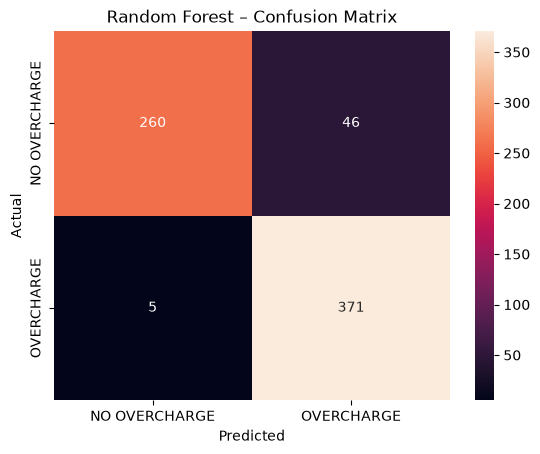

In [348]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_labels)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest – Confusion Matrix")
plt.show()

* KOKKUVÕTE: 

Logistic Regression:

leidis 44 overcharge'i
aga valepositiivseid oli 237

Random Forest, threshold 0.4:

leidis 28 overcharge'i
valepositiivseid ainult 50

# RANDOM FORESTI TUUNIMINE/ARENDAMINE : n_estimators, max_depth, min_samples_leaf

* max_depth=10 pani mudeli leidma väga palju positiivseid juhtumeid. Threshold 0.7 ütleb nüüd:

"Okei, ära nimeta sõitu overcharge'iks lihtsalt sellepärast, et mudel on natuke kahtlustav. Ole klassi 1 määramisel üsna kindel."

* Selle tulemus:

Precision 40% → mudeli poolt overcharge'iks märgitud sõitudest 40% olid päriselt overcharge'id.
Recall 44% → tegelikest overcharge'idest leidis mudel 44%.
F1 42% → nende kahe kompromiss on senisest parem.

* CONFUSION MATRIX

* RANDOM FORESTI min_samples_leaf ütleb: Ühes puu lõpp-harus peab olema vähemalt X vaatlust

In [354]:
rf_leaf5 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=100
)

rf_leaf5.fit(x_train, y_train)

y_rf_leaf5_pred = rf_leaf5.predict(x_test)

print(classification_report(y_test, y_rf_leaf5_pred))

               precision    recall  f1-score   support

NO OVERCHARGE       0.94      0.87      0.90       306
   OVERCHARGE       0.90      0.96      0.93       376

     accuracy                           0.92       682
    macro avg       0.92      0.91      0.91       682
 weighted avg       0.92      0.92      0.92       682



In [355]:
y_rf_leaf5_prob = rf_leaf5.predict_proba(x_test)[:, 1]

* Recall = 33 / 70 = 47%

→ mudel leiab umbes pooled tegelikud ülehinnatud sõidud.

Precision = 33 / (33 + 51) = 39%

→ kui mudel ütleb OVERCHARGE, siis umbes 39% juhtudest on see päriselt overcharge.

| Mudel                                    | Precision 1 | Recall 1 |     F1 1 |
| ---------------------------------------- | ----------: | -------: | -------: |
| Logistic Regression balanced             |        0.16 | **0.63** |     0.25 |
| Random Forest                            |        0.35 |     0.11 |     0.17 |
| Random Forest balanced                   |        0.43 |     0.33 |     0.37 |
| RF depth=10, threshold 0.70              |        0.40 |     0.44 |     0.42 |
| **RF depth=10 + leaf=5, threshold 0.70** |    **0.39** | **0.47** | **0.43** |


## RANDOM FOREST VISUAALID: TOP 15 OVERCHARGE PÕHJUSTAJAD

* IMPORTANCE TABEL LOOMINE

In [357]:
rf_balanced.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",100
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1

In [358]:
importance = pd.DataFrame({
    "feature": x_train.columns,
    "importance": rf_balanced.feature_importances_
})

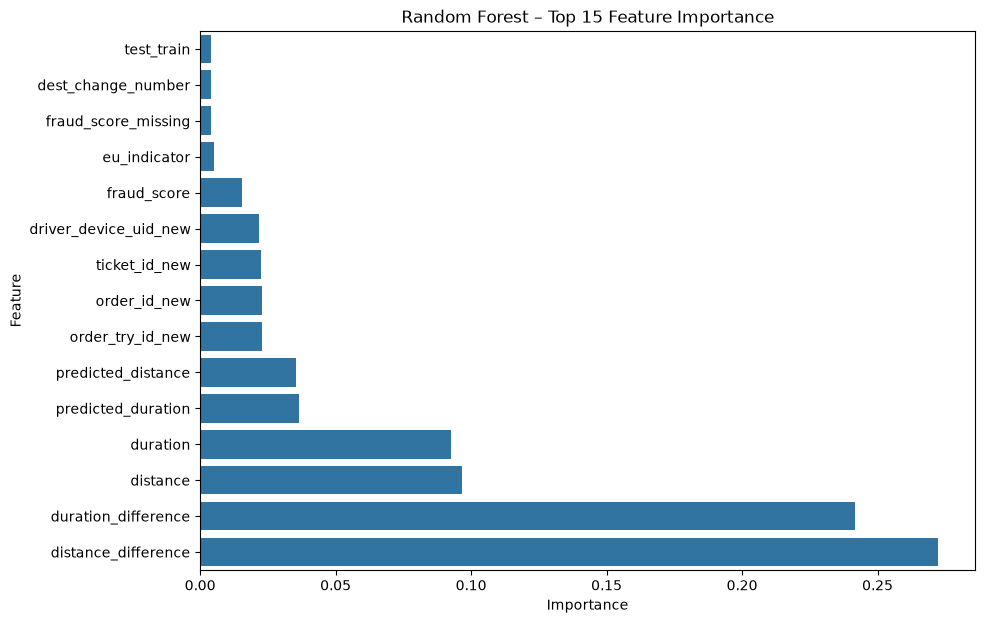

In [359]:
importance_top15 = importance.sort_values(
    "importance",
    ascending=False
).head(15)

importance_top15 = importance_top15.sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_top15,
    x="importance",
    y="feature"
)

plt.title("Random Forest – Top 15 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

* PERMUTATION IMPORTANCE 

Kui palju mudeli tulemus halveneb, kui ühe tunnuse väärtused juhuslikult segamini ajada?


* permutation_importance teeb teistmoodi määratud andmete uurimisel

Ta võtab juba treenitud mudeli ja küsib:

"Mis juhtub mudeli täpsusega, kui ma ühe tunnuse väärtused juhuslikult segamini ajan?"

* TABEL PERMUTATION IMPORTANCE

|  # | Feature                 | Importance | Mida see ütleb                                  |
| -: | ----------------------- | ---------: | ----------------------------------------------- |
|  1 | `metered_price`         | **0.1739** | Kõige suurema mõjuga tunnus                     |
|  2 | `gps_confidence`        | **0.1614** | Peaaegu sama oluline kui hind                   |
|  3 | `distance`              | **0.0901** | Sõidu pikkus on oluline                         |
|  4 | `eu_indicator`          | **0.0789** | Piirkond/EL-indikaator annab mudelile infot     |
|  5 | `order_id_new`          | **0.0567** | ⚠️ võimalik probleemne tunnus                   |
|  6 | `upfront_price_missing` | **0.0539** | Puuduv upfront-hind on üllatavalt informatiivne |
|  7 | `fraud_score_missing`   | **0.0449** | Ka fraud score'i puudumine annab mudelile infot |
|  8 | `order_try_id_new`      | **0.0374** | ⚠️ samuti tasub kriitiliselt vaadata            |
|  9 | `upfront_price`         | **0.0340** | Väiksem mõju kui `metered_price`                |
| 10 | `driver_device_uid_new` | **0.0336** | Seadme tunnus annab mudelile infot              |
| 11 | `fraud_score`           | **0.0292** | Mõõdetud fraud score ise on tagasihoidlikum     |
| 12 | `hour`                  | **0.0273** | Kellaaeg mõjutab mõnevõrra                      |


Kõige huvitavamad leiud

1. metered_price + gps_confidence moodustavad juba ~33,5% kogu importance'ist.

See on päris tugev signaal:

mudel kasutab väga palju tegelikku sõiduhinda ja GPS-andmete kvaliteeti.

* ORDER_ID_NEW JA ORDER_TRY_ID_NEW TULBA KÕRVALE HEITMINE MUDELIST

* SPLITIME

In [366]:
x_train_no_order, x_test_no_order, y_train_no_order, y_test_no_order = train_test_split(
    x_rf_no_order,
    y,
    test_size=0.2,
    random_state=100
)

* UUS TREENITUD RF MUDEL ILMA ORDER_ID_NEW ja ORDER_TRY_ID_NEW

In [367]:
model_no_order = RandomForestClassifier(random_state=100)

model_no_order.fit(x_train_no_order, y_train_no_order)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",100
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [368]:
y_pred_no_order = model_no_order.predict(x_test_no_order)

* TULEMUS

In [369]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_no_order, y_pred_no_order)

array([[292,  14],
       [  8, 368]])

In [370]:
x_id = x[["order_id_new", "order_try_id_new"]].copy()

In [371]:
x_train_id, x_test_id, y_train_id, y_test_id = train_test_split(
    x_id,
    y,
    test_size=0.2,
    random_state=100
)

In [372]:
model_id = RandomForestClassifier(random_state=100)

model_id.fit(x_train_id, y_train_id)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",100
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [373]:
y_pred_id = model_id.predict(x_test_id)

In [374]:
confusion_matrix(y_test_id, y_pred_id)

array([[158, 148],
       [108, 268]])

In [375]:
print(classification_report(y_test_id, y_pred_id))

               precision    recall  f1-score   support

NO OVERCHARGE       0.59      0.52      0.55       306
   OVERCHARGE       0.64      0.71      0.68       376

     accuracy                           0.62       682
    macro avg       0.62      0.61      0.61       682
 weighted avg       0.62      0.62      0.62       682



## KUNA ORDER_ID_NEW veergudel KORDUSI siis õpetame mudelit eristama ja võtma ühe vääringuna

* SELLEKS GROUPSHUFFLESPLIT

In [376]:
from sklearn.model_selection import GroupShuffleSplit

In [377]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=100
)

train_idx, test_idx = next(
    gss.split(x, y, groups=x["order_id_new"])
)

x_train_group = x.iloc[train_idx]
x_test_group = x.iloc[test_idx]

y_train_group = y.iloc[train_idx]
y_test_group = y.iloc[test_idx]

* KONTROLL ET ORDERID EI KATTUKS

In [378]:
len(
    set(x_train_group["order_id_new"]) &
    set(x_test_group["order_id_new"])
)

0

* RANDOM FORESTI MUDELI III TREENING

* 1) MODEL GROUP - ID-d alles + groupshufflesplit order_id_new jägi

In [379]:
model_group = RandomForestClassifier(random_state=100)

model_group.fit(
    x_train_group,
    y_train_group
)

y_pred_group = model_group.predict(x_test_group)

In [380]:
x_group_no_id = x.drop(
    columns=["order_id_new", "order_try_id_new"]
)

In [381]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=100
)

train_idx, test_idx = next(
    gss.split(
        x_group_no_id,
        y,
        groups=x["order_id_new"]
    )
)

x_train_group_no_id = x_group_no_id.iloc[train_idx]
x_test_group_no_id = x_group_no_id.iloc[test_idx]

y_train_group_no_id = y.iloc[train_idx]
y_test_group_no_id = y.iloc[test_idx]

* MODEL_GROUP_NO_ID - ID eemaldatud + sama GroupShufflesplit

In [383]:
model_group_no_id = RandomForestClassifier(random_state=100)

model_group_no_id.fit(
    x_train_group_no_id,
    y_train_group_no_id
)

y_pred_group_no_id = model_group_no_id.predict(
    x_test_group_no_id
)

In [384]:
print(confusion_matrix(y_test_group_no_id, y_pred_group_no_id))

print(classification_report(y_test_group_no_id, y_pred_group_no_id))

[[285  16]
 [ 19 372]]
               precision    recall  f1-score   support

NO OVERCHARGE       0.94      0.95      0.94       301
   OVERCHARGE       0.96      0.95      0.96       391

     accuracy                           0.95       692
    macro avg       0.95      0.95      0.95       692
 weighted avg       0.95      0.95      0.95       692



* METERED PRICE seos OVERPAID RIDE TICKETITEGA

In [385]:
bolt_andmed.groupby("overpaid_ride_ticket")["metered_price"].describe()

,count,mean,std,min,25%,50%,75%,max
overpaid_ride_ticket,,,,,,,,
0,4586.0,6988.139562,14632.382346,2.00,5.12,10.765,9000.0,194483.52
1,337.0,21747.377329,23218.078846,5.52,7978.74,15039.720,25812.5,157006.04


# METERED PRICE BOXPLOT

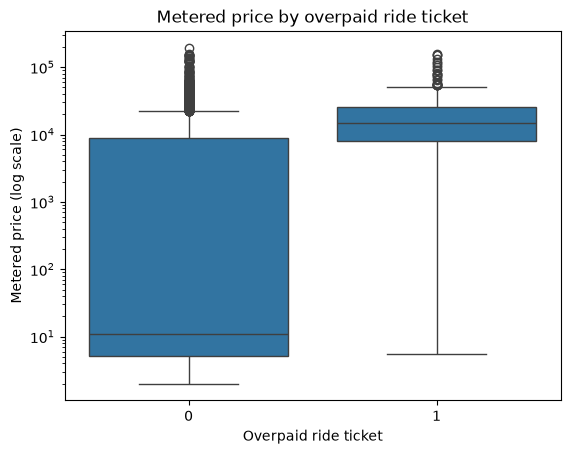

In [386]:
sns.boxplot(
    data=bolt_andmed,
    x="overpaid_ride_ticket",
    y="metered_price"
)

plt.yscale("log")
plt.xlabel("Overpaid ride ticket")
plt.ylabel("Metered price (log scale)")
plt.title("Metered price by overpaid ride ticket")
plt.show()

In [387]:
bolt_andmed.groupby(
    ["eu_indicator", "gps_confidence"]
)["overpaid_ride_ticket"].agg(
    ["count", "sum", "mean"]
)

count  sum      mean
eu_indicator gps_confidence                      
0            0                 858  197  0.229604
             1                1315  127  0.096578
1            0                 127    4  0.031496
             1                2643    9  0.003405

* EU, GPS, SÕIDUD, TICKETITE OMAVAHELINE VÕRDLUS + RATE

| EU | GPS | Sõite | Ticketid |       Rate |
| -- | --- | ----: | -------: | ---------: |
| 0  | 0   |   858 |      197 | **22.96%** |
| 0  | 1   | 1 315 |      127 |  **9.66%** |
| 1  | 0   |   127 |        4 |  **3.15%** |
| 1  | 1   | 2 643 |        9 |  **0.34%** |


In [388]:
pd.crosstab(
    bolt_andmed["eu_indicator"],
    bolt_andmed["prediction_price_type"],
    normalize="index"
)

prediction_price_type,prediction,upfront,upfront_destination_changed,upfront_waypoint_changed
eu_indicator,,,,
0,0.588127,0.405890,0.005983,0.000000
1,0.000364,0.927273,0.070909,0.001455


* EU INDIKAATORI ja PREDICTION PRICE TYPE SEOS

| EU    | prediction |    upfront | destination changed | waypoint changed |
| ----- | ---------: | ---------: | ------------------: | ---------------: |
| **0** | **58.81%** |     40.59% |               0.60% |               0% |
| **1** |  **0.04%** | **92.73%** |               7.09% |            0.15% |
